In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

#jax.config.update('jax_platform_name', 'cpu')

# Set default device to CPU


from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE, VPSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/jax/_src/api_util.py:174: SyntaxWarning: Jitted function has static_argnums=(3, 4), but only accepts 4 positional arguments. This warning will be replaced by an error after 2022-08-20 at the earliest.
  warnings.warn(f"Jitted function has {argnums_name}={argnums}, "


In [2]:
prior = Normal(jnp.zeros((1,)), jnp.ones((1,))) 

In [3]:

# # VESDE 
# T = 1.
# T_min = 1e-2
# sigma_min = 1e-1
# sigma_max = 10.

# thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
# p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
# sde = VESDE(p0, sigma_min=sigma_min , sigma_max=sigma_max)

# def output_scale_fn(t, x):
#     scale = sde.marginal_stddev(t, jnp.ones_like(x))
#     return (1/scale * x).reshape(x.shape)

# def weight_fn(t):
#     #return jnp.clip(sde.diffusion(t, jnp.ones((1,1,1)))**2, 1e-4)
#     return jnp.ones((1,1,1))

In [45]:

# VPSDE 
T = 1.
T_min = 1e-1
beta_min = 0.01
beta_max = 10.

thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VPSDE(p0, beta_min=beta_min , beta_max=beta_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    scale = jnp.clip(scale, 1e-3, 1e3)
    return (1/scale * x).reshape(x.shape)

def weight_fn(t):
    #return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-1
    return jnp.ones((1,1,1))

[1] []


In [46]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 50
activation = jax.nn.gelu
num_hidden = 6
layer_norm = True

def score_net(a, theta, x_t0, x_t1):
    
    context = jnp.concatenate([x_t0, x_t1], axis=-1) 

    time_embedding = GaussianFourierEmbedding(128)(a[..., None])
    
    h1 = hk.Linear(hidden_dim//2)(context)
    h2 = hk.Linear(hidden_dim - hidden_dim//2)(theta)
    
    h = activation(jnp.concatenate([h1, h2], axis=-1))

    for _ in range(num_hidden - 1):
        h_new = hk.Linear(hidden_dim)(h)
        h_new += hk.Linear(hidden_dim)(time_embedding)
        h = activation(h_new)

        if layer_norm:
            h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

    out = hk.Linear(theta.shape[-1])(h)
    out = output_scale_fn(a, out)

    return out.reshape(theta.shape)


In [47]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones((10,)), thetas[:10], jnp.ones((10, 1)), jnp.ones((10, 1))) # Initialize the parameters of the model

In [48]:
sigma_x0 = 10.
def generate_data(key, n):
    key1, key2, key3 = jax.random.split(key, 3)
    
    theta_batch = jax.random.normal(key1, (n,1))
    x_t = jax.random.normal(key2, (n,1))*sigma_x0    
    x_t1 =  x_t + theta_batch + jax.random.normal(key3, (n,1)) 
    return theta_batch, x_t, x_t1


In [49]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [50]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [51]:


def loss_fn(params, key, batch_size= 1024):

    rng_time, rng_data, rng_sample = jax.random.split(key, 3)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size,), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1, axis=-1)
    
    return loss


In [52]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [53]:

#optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adam(5e-4))
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [54]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [55]:
key = jrandom.PRNGKey(0)

In [56]:
for _ in range(20):
    l = 0
    for i in range(2000):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 2000
    print(l)

1.468284
1.3821218
1.3905252


KeyboardInterrupt: 

In [21]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [22]:
theta_o = jnp.array([-1.])

x_0 = jnp.array([0.])
xs = [x_0]
num_T = 5
for i in range(num_T):
    x_1 = x_0 + theta_o + jax.random.normal(jrandom.PRNGKey(i+2), (1,))
    x_0 = x_1
    xs.append(x_1)
    
x_o = jnp.array(xs)[:,0]

In [23]:
def xi(mu, sigma):
    return - 0.5*(jnp.log(2*jnp.pi) - jnp.log(1/sigma**2) + mu**2/sigma**2)

def Lambda_fn(sigmas_a, sigma_prior_a):
    N = len(sigmas_a)  
    return jnp.sum(1/sigmas_a**2) + (1-N) * 1/sigma_prior_a**2

def eta_fn(mu_a, sigma_a, mu_prior_a, sigma_prior_a):
    N = len(mu_a) 
    return jnp.sum(mu_a/sigma_a**2) + (1-N) * mu_prior_a/sigma_prior_a**2


In [38]:
mu0 = 0.
sigma0 = 1.
def marginal_prior(a):
    # Marginal prior at a
    marginal_mean = sde.marginal_mean(a, jnp.ones_like(a))
    marginal_std = sde.marginal_stddev(a, jnp.ones_like(a))
    
    return marginal_mean*mu0, jnp.sqrt(marginal_mean**2*sigma0**2 + marginal_std**2)

def prior_fn(a, theta):
    # Prior at a, theta
    m, s = marginal_prior(a)
    score = jax.grad(lambda x: jax.scipy.stats.norm.logpdf(x, m,s).sum())(theta)
    return 1/s**2, score

def score_approx(a, theta, x_o):
    prior_precision_a, prior_score_a = prior_fn(a, theta)
    N = (len(x_o) - 1)
    x_past = x_o[:-1, None]
    x_future = x_o[1:, None]
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    scores = model_fn(params, a, theta_batch, x_past, x_future)
    marginal_precision_a = 1/sde.marginal_stddev(a)**2 * jnp.ones_like(scores)
    Lam = (1-N) * prior_precision_a + jnp.sum(marginal_precision_a, axis=0)
    score = (1-N)*prior_precision_a * prior_score_a + jnp.sum(marginal_precision_a * scores, axis=0)
    score = score / Lam
    return score
    
    

In [25]:
def score_approx(a, theta, x_o):

    x_past = x_o[:-1, None]
    x_future = x_o[1:, None]
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    scores = model_fn(params, a, theta_batch, x_past, x_future)
    N = scores.shape[0]
    _, prior_score_a = prior_fn(a, theta)
    
    return (1-N)*prior_score_a + jnp.sum(scores, axis=0)

In [39]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    #x1, x2 = jnp.split(x_o, 2)
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    N = len(x_o) - 1
    # std_t_last = sde.marginal_stddev(1., jnp.ones_like(x_o[-1]))
    # std_t = sde.marginal_stddev(t, jnp.ones_like(x_o[-1]))
    
    # theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    # increment_scores = model_fn(params, t, theta_batch, x_past, x_future)

    # prior_score = (1-t)* std_t_last**2/std_t**2 * jax.grad(lambda x: prior.log_prob(x).sum())(theta) 
    # prior_score = (1-t)* jax.grad(lambda x: prior.log_prob(x).sum())(theta)
    # score = increment_scores.sum(axis=0) -  (N-1)*prior_score
    score = score_approx(t, theta, x_o)
    

    score = score.reshape(theta.shape)

    f =  sde.drift(t,theta) - sde.diffusion(t,theta)**2 * score
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,theta):
    #t = T - t
    b =  sde.diffusion(t,theta) 
    return b

In [40]:

end_std = jnp.squeeze(sde.marginal_stddev(jnp.ones(1)))
end_mean = jnp.squeeze(sde.marginal_mean(jnp.ones(1)))

def sample_fn(key, shape,x_o, time_steps=500):
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    Ts = x_o.shape[0] - 1
    x_T = jax.random.normal(key1, shape + (1,)) * end_std / Ts  + end_mean
    
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, x_o=x_o), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [41]:
def true_posterior(x_o):
    
    T = x_o.shape[0] 
    x_first = x_o[0, None]
    x_last = x_o[-1,None]
    
    mean_posterior = (x_last- x_first)/(T+1)
    std_posterior = 1/jnp.sqrt(T+1)
    return Normal(mean_posterior, std_posterior)

In [42]:
samples = sample_fn(jrandom.PRNGKey(0), (10000,), x_o)

In [43]:
l = jnp.linspace(-3, 3, 1000)
Z = jnp.exp(true_posterior(x_o).log_prob(l[:,None]).sum(-1))

(-3.0, 3.0)

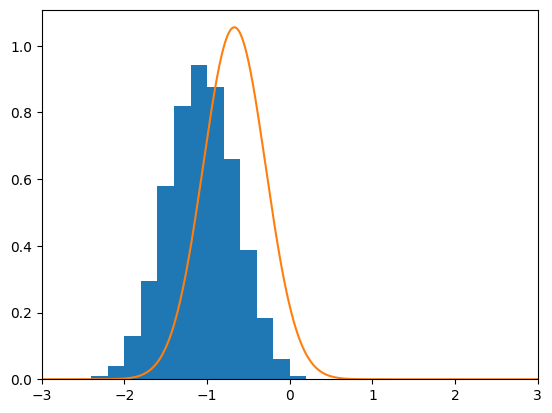

In [44]:
plt.hist(samples[:, -1,0], density=True, range=(-5,5), bins=50)
_ = plt.plot(l,Z)
plt.xlim(-3,3)